# Part 3 - Machine Learning Model
###  Ronojoy Mitra

**Business use case.** Forecast chronic disease prevalence for a geographic area from
social, economic, and environmental factors, so the insurer can anticipate claim burden,
design products, and plan territories 

**Why this needs the hybrid data lake.** The predictors and the target come from *different
source systems*:

| Role | Source | Publisher |
|---|---|---|
| Predictors | Social Vulnerability Index (SVI) | CDC/ATSDR, derived from US Census / ACS |
| Predictors | Annual Air Quality Index | US EPA |
| **Target** | PLACES chronic disease prevalence | CDC |

This separation is deliberate. PLACES values are not direct measurements, they are
small-area *model estimates* derived from BRFSS survey data. Predicting one PLACES measure
from another would partly mean predicting a model's output from the same model's other
outputs, and any strong result would be partly an artefact. Keeping predictors and target
in separate systems avoids that, and is the concrete payoff of the Part 2 data lake.

**On the Synthea data.** The 607 synthetic patients loaded into PostgreSQL are *not* used
here. Synthea generates each patient independently from national disease-progression
models, so its conditions do not correlate with real county health statistics. That data
exists to exercise the physical design and the quote workflow, not to produce analytical
findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.cluster import KMeans

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
RANDOM_STATE = 42

## 1. Load the feature table

`ml_features.csv` is produced by `part3_ml_features.py`, which joins the three data lake
sources at census-tract level: SVI and PLACES join directly on tract FIPS, while EPA air
quality is county-level and is attached to every tract in its county.

In [2]:
df = pd.read_csv('ml_features.csv', dtype={'tract_fips': str, 'county_fips': str})

print(f'{len(df):,} census tracts across {df.county_fips.nunique()} New York counties')
print(f'{df.shape[1]} columns')
df[['tract_fips', 'county_name', 'total_pop', 'ep_pov150',
    'ep_nohsdp', 'diabetes', 'obesity', 'median_aqi']].head()

5,289 census tracts across 62 New York counties
37 columns


,tract_fips,county_name,total_pop,ep_pov150,ep_nohsdp,diabetes,obesity,median_aqi
0,36001000100,Albany County,2259,48.0,22.7,16.5,44.4,39.0
1,36001000201,Albany County,2465,49.2,17.3,15.6,44.6,39.0
2,36001000202,Albany County,2374,46.7,13.2,15.0,45.1,39.0
3,36001000301,Albany County,2837,39.9,15.3,13.7,41.6,39.0
4,36001000302,Albany County,3200,26.6,4.3,8.4,29.4,39.0


## 2. Feature selection and the fairness constraint

The SVI provides 14 candidate socioeconomic predictors. Four are deliberately **excluded**
before any modelling, because using them to inform insurance pricing would raise
discrimination concerns

| Excluded | Reason |
|---|---|
| `ep_minrty` | Racial / ethnic composition, a direct protected characteristic. Pricing on it is the statistical form of redlining. |
| `ep_limeng` | Limited English proficiency, a close proxy for national origin. |
| `ep_disabl` | Disability status, protected under the ADA, and health-status rating is restricted under the ACA. |
| `ep_sngpnt` | Single-parent households, correlates strongly with sex, so it functions as a sex proxy. |

**Age is retained.** `ep_age65` and `ep_age17` stay in the model because age-based rating is
long established, legal, and actuarially standard in health and life insurance, unlike the
four above.

This directly addresses the project brief's requirement to *"safeguard enterprises against
potential bias subsumed in socio-technical systems and limit the decision power of such
systems to ensure fairness, accountability, and transparency."*

In [3]:
# Excluded from all production modelling
EXCLUDED = {
    'ep_minrty': 'race / ethnicity',
    'ep_limeng': 'national origin proxy',
    'ep_disabl': 'disability (ADA / ACA)',
    'ep_sngpnt': 'sex proxy',
}

# The 10 predictors actually used
FEATURES = [
    'ep_pov150',   # % below 150% of the poverty line
    'ep_unemp',    # % unemployed
    'ep_hburd',    # % housing cost-burdened
    'ep_nohsdp',   # % without a high school diploma
    'ep_uninsur',  # % without health insurance
    'ep_age65',    # % aged 65+
    'ep_age17',    # % aged 17 and under
    'ep_crowd',    # % in crowded housing
    'ep_noveh',    # % without vehicle access
    'ep_noint',    # % without internet access
]

TARGETS = ['diabetes', 'obesity', 'bphigh', 'chd', 'stroke', 'copd', 'cancer']
PRIMARY_TARGET = 'diabetes'

print(f'Using {len(FEATURES)} predictors; {len(EXCLUDED)} excluded on fairness grounds:')
for k, v in EXCLUDED.items():
    print(f'  {k:12s} -> {v}')

Using 10 predictors; 4 excluded on fairness grounds:
  ep_minrty    -> race / ethnicity
  ep_limeng    -> national origin proxy
  ep_disabl    -> disability (ADA / ACA)
  ep_sngpnt    -> sex proxy


## 3. Data preparation

Rows missing any predictor or the target are dropped. CDC marks suppressed values with
`-999`, which the feature-extraction step already converted to `NaN`, so those tracts fall
out here rather than being silently treated as real measurements.

In [4]:
data = df.dropna(subset=FEATURES + [PRIMARY_TARGET]).copy()
print(f'{len(data):,} of {len(df):,} tracts usable ({len(df) - len(data)} dropped)')

X = data[FEATURES]
y = data[PRIMARY_TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)
print(f'Train: {len(X_train):,} tracts   Test: {len(X_test):,} tracts')

data[PRIMARY_TARGET].describe().round(2)

5,249 of 5,289 tracts usable (40 dropped)
Train: 3,936 tracts   Test: 1,313 tracts


count    5249.00
mean       11.42
std         3.45
min         0.80
25%         9.20
50%        11.00
75%        13.20
max        32.70
Name: diabetes, dtype: float64

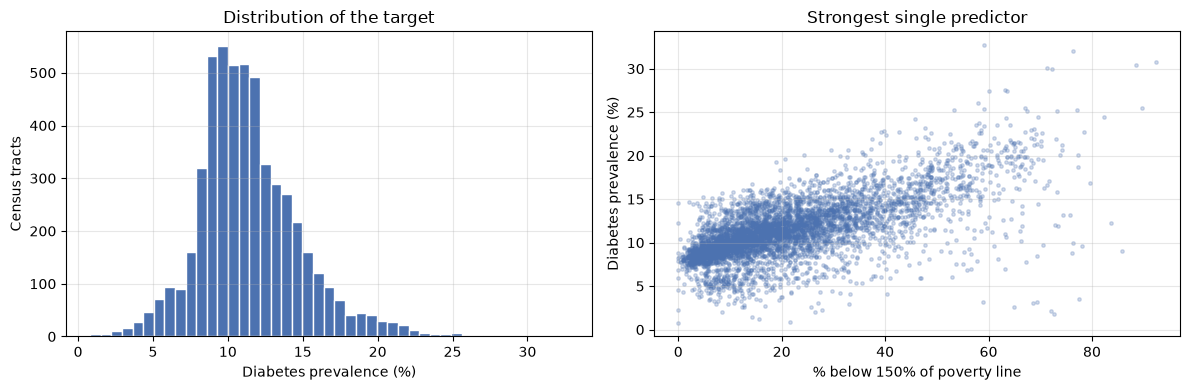

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(data[PRIMARY_TARGET], bins=45, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Diabetes prevalence (%)')
axes[0].set_ylabel('Census tracts')
axes[0].set_title('Distribution of the target')

axes[1].scatter(data['ep_pov150'], data[PRIMARY_TARGET], s=6, alpha=0.25, color='#4C72B0')
axes[1].set_xlabel('% below 150% of poverty line')
axes[1].set_ylabel('Diabetes prevalence (%)')
axes[1].set_title('Strongest single predictor')

plt.tight_layout(); plt.show()

## 4. Supervised learning - regression

Two algorithms:

- **Linear regression** gives interpretable, signed coefficients, useful for explaining
  *direction* to a business audience. Features are standardised first so coefficients are
  comparable to each other rather than reflecting arbitrary units.
- **Random forest** (200 trees) captures non-linearities and interactions a linear model
  cannot, and typically scores higher.

Scoring is on a held-out 25% test set the models never saw during training, plus 5-fold
cross-validation to check the result is not an artefact of one lucky split.

In [6]:
linear = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
forest = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                               n_jobs=-1).fit(X_train, y_train)

results = {}
for name, model in [('Linear Regression', linear), ('Random Forest', forest)]:
    pred = model.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, pred),
        'MAE': mean_absolute_error(y_test, pred),
    }
    print(f'{name:20s} R2 = {results[name]["R2"]:.3f}   '
          f'MAE = {results[name]["MAE"]:.2f} percentage points')

cv = cross_val_score(make_pipeline(StandardScaler(), LinearRegression()),
                     X, y, cv=5, scoring='r2')
print(f'\nLinear 5-fold CV R2: {cv.mean():.3f} (+/- {cv.std():.3f})')
print('The CV spread is wider than the single split, indicating some sensitivity')
print('to which tracts land in training - worth noting rather than glossing over.')

Linear Regression    R2 = 0.645   MAE = 1.46 percentage points
Random Forest        R2 = 0.722   MAE = 1.27 percentage points

Linear 5-fold CV R2: 0.533 (+/- 0.171)
The CV spread is wider than the single split, indicating some sensitivity
to which tracts land in training - worth noting rather than glossing over.


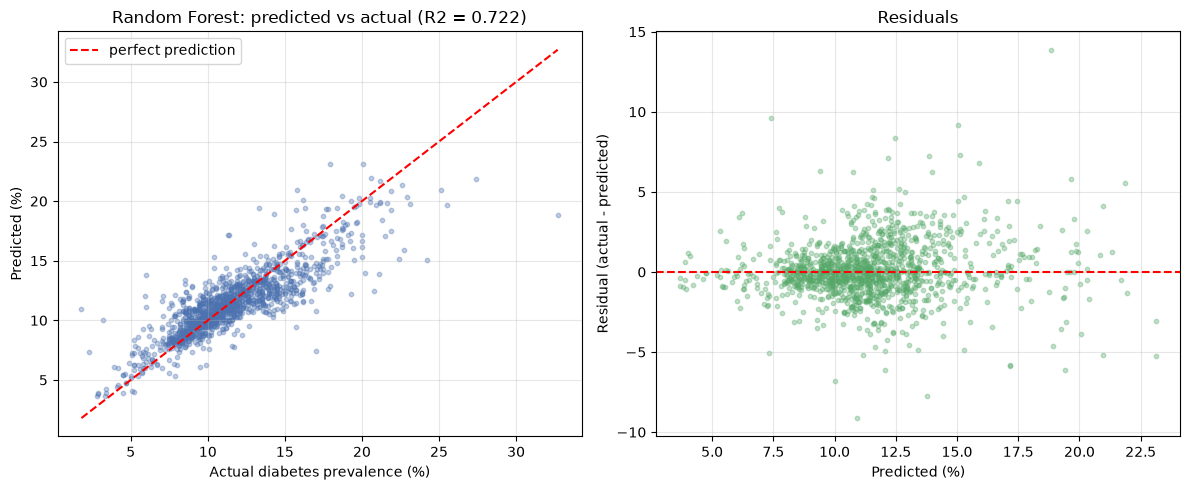

In [7]:
pred = forest.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, pred, s=10, alpha=0.35, color='#4C72B0')
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='perfect prediction')
axes[0].set_xlabel('Actual diabetes prevalence (%)')
axes[0].set_ylabel('Predicted (%)')
axes[0].set_title(f'Random Forest: predicted vs actual (R2 = {results["Random Forest"]["R2"]:.3f})')
axes[0].legend()

residuals = y_test - pred
axes[1].scatter(pred, residuals, s=10, alpha=0.35, color='#55A868')
axes[1].axhline(0, color='r', ls='--', lw=1.5)
axes[1].set_xlabel('Predicted (%)')
axes[1].set_ylabel('Residual (actual - predicted)')
axes[1].set_title('Residuals')

plt.tight_layout(); plt.show()

### What drives the predictions

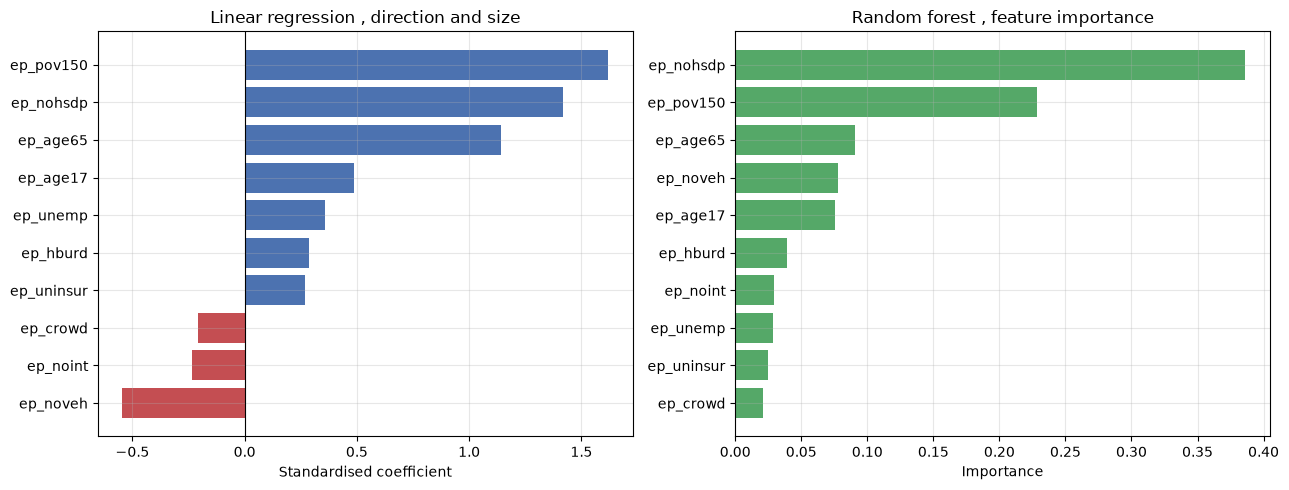

Top drivers:
  ep_nohsdp    0.386
  ep_pov150    0.229
  ep_age65     0.091
  ep_noveh     0.077
  ep_age17     0.075


In [8]:
coefs = pd.Series(linear.named_steps['linearregression'].coef_,
                  index=FEATURES).sort_values()
importances = pd.Series(forest.feature_importances_,
                        index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#C44E52' if v < 0 else '#4C72B0' for v in coefs]
axes[0].barh(coefs.index, coefs.values, color=colors)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Standardised coefficient')
axes[0].set_title('Linear regression , direction and size')

axes[1].barh(importances.index, importances.values, color='#55A868')
axes[1].set_xlabel('Importance')
axes[1].set_title('Random forest , feature importance')

plt.tight_layout(); plt.show()

print('Top drivers:')
for k, v in importances.sort_values(ascending=False).head(5).items():
    print(f'  {k:12s} {v:.3f}')

## 5. Generalisation to other chronic conditions

The same 10 predictors are applied to the other six PLACES measures, to check the approach
is not specific to diabetes.

,condition,R2,MAE (pp),tracts
6,cancer,0.831,0.82,5249
5,copd,0.769,0.78,5249
0,diabetes,0.722,1.27,5249
4,stroke,0.720,0.40,5249
3,chd,0.712,0.60,5249
1,obesity,0.650,3.10,5249
2,bphigh,0.632,2.59,5249


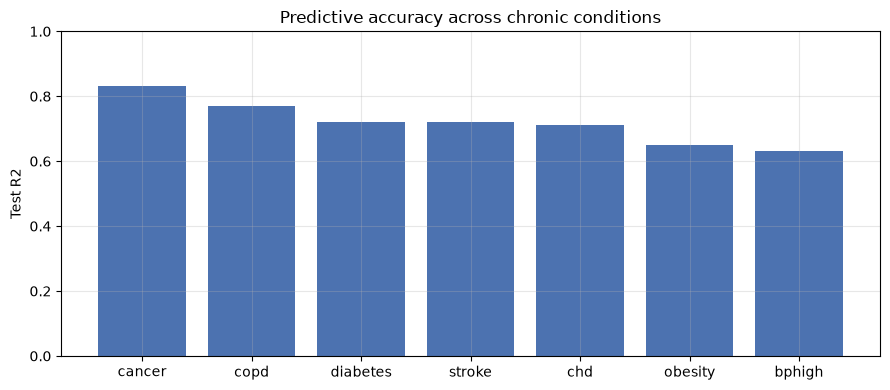

In [9]:
rows = []
for t in TARGETS:
    d = df.dropna(subset=FEATURES + [t])
    Xt, yt = d[FEATURES], d[t]
    Xtr, Xte, ytr, yte = train_test_split(Xt, yt, test_size=0.25,
                                          random_state=RANDOM_STATE)
    m = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(Xtr, ytr)
    p = m.predict(Xte)
    rows.append({'condition': t,
                 'R2': round(r2_score(yte, p), 3),
                 'MAE (pp)': round(mean_absolute_error(yte, p), 2),
                 'tracts': len(d)})

summary = pd.DataFrame(rows).sort_values('R2', ascending=False)
display(summary)

plt.figure(figsize=(9, 4))
plt.bar(summary.condition, summary.R2, color='#4C72B0')
plt.ylabel('Test R2'); plt.ylim(0, 1)
plt.title('Predictive accuracy across chronic conditions')
plt.tight_layout(); plt.show()

## 6. Fairness analysis

The four excluded features were removed on principle, not because they were weak. This
section measures the price of that decision, so the trade-off is documented rather than
hidden. Four feature sets are compared, from unrestricted to progressively more
constrained.

,feature set,n features,R2,MAE (pp)
0,A. All 14 features,14,0.838,0.98
1,B. minus race + language,12,0.737,1.25
2,C. PRODUCTION SET (10),10,0.722,1.27
3,D. also minus age bands,8,0.644,1.40


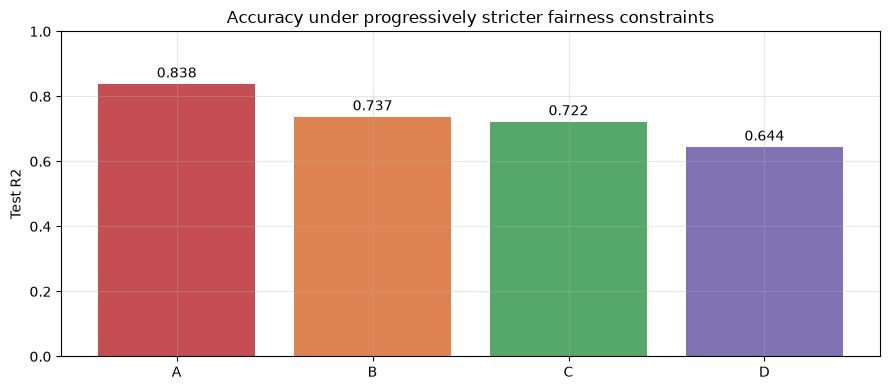

In [10]:
SETS = {
    'A. All 14 features':            FEATURES + list(EXCLUDED),
    'B. minus race + language':      FEATURES + ['ep_disabl', 'ep_sngpnt'],
    'C. PRODUCTION SET (10)':        FEATURES,
    'D. also minus age bands':       [f for f in FEATURES if f not in ('ep_age65', 'ep_age17')],
}

rows = []
for name, feats in SETS.items():
    d = df.dropna(subset=feats + [PRIMARY_TARGET])
    Xs, ys = d[feats], d[PRIMARY_TARGET]
    Xtr, Xte, ytr, yte = train_test_split(Xs, ys, test_size=0.25,
                                          random_state=RANDOM_STATE)
    m = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE,
                              n_jobs=-1).fit(Xtr, ytr)
    p = m.predict(Xte)
    rows.append({'feature set': name, 'n features': len(feats),
                 'R2': round(r2_score(yte, p), 3),
                 'MAE (pp)': round(mean_absolute_error(yte, p), 2)})

fair = pd.DataFrame(rows)
display(fair)

plt.figure(figsize=(9, 4))
colors = ['#C44E52', '#DD8452', '#55A868', '#8172B3']
plt.bar(range(len(fair)), fair.R2, color=colors)
plt.xticks(range(len(fair)), [s.split('.')[0] for s in fair['feature set']])
plt.ylabel('Test R2'); plt.ylim(0, 1)
for i, v in enumerate(fair.R2):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.title('Accuracy under progressively stricter fairness constraints')
plt.tight_layout(); plt.show()

### Interpretation

- **A → B** is the expensive step. Removing racial composition and limited-English costs
  roughly 0.10 R². Before removal, `ep_minrty` was the *single strongest predictor* in the
  model, stronger than poverty. That is precisely why it cannot be used: a model whose
  dominant signal is neighbourhood racial composition, applied to pricing or underwriting,
  is statistical redlining regardless of intent.
- **B → C** is nearly free. Dropping disability and single-parent share costs only ~0.013
  R², so there is no real trade-off in excluding them as well.
- **C → D** is expensive again, which is why age is retained: it carries genuine signal, and
  unlike the other four it is a legal, actuarially standard rating factor in health and
  life insurance.

**Set C is the production model.** The retained predictors: poverty, education,
uninsurance, housing, vehicle and internet access, are causally plausible drivers of
health outcomes rather than proxies for who a person is, and they are actionable: they
point toward interventions (outreach, access, preventive programmes) rather than
exclusions.

## 7. Unsupervised learning - county risk tiers

Regression predicts a number. For territory planning and product design the business needs
*segments*. K-means groups the 62 counties by their socioeconomic profile, with no target
variable supplied, the disease rates are only used afterwards, to interpret what the
clusters turned out to mean.

62 counties


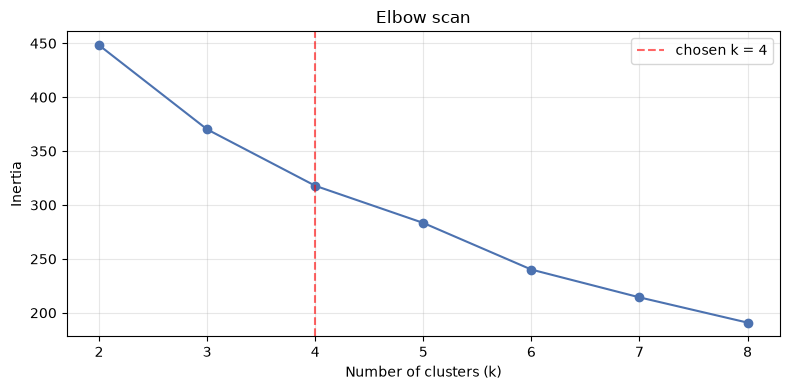

In [11]:
county = (df.groupby(['county_fips', 'county_name'])[FEATURES + TARGETS]
            .mean()
            .dropna(subset=FEATURES)
            .reset_index())
print(f'{len(county)} counties')

X_county = StandardScaler().fit_transform(county[FEATURES])

inertias = []
for k in range(2, 9):
    inertias.append(KMeans(n_clusters=k, random_state=RANDOM_STATE,
                           n_init=10).fit(X_county).inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertias, 'o-', color='#4C72B0')
plt.axvline(4, color='r', ls='--', alpha=0.6, label='chosen k = 4')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia')
plt.title('Elbow scan'); plt.legend()
plt.tight_layout(); plt.show()

In [12]:
K = 4
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_county)
county['cluster'] = km.labels_

# Relabel so tier 1 = lowest risk (raw cluster numbers are arbitrary)
order = county.groupby('cluster')[PRIMARY_TARGET].mean().sort_values().index
county['risk_tier'] = county['cluster'].map({c: i + 1 for i, c in enumerate(order)})

tiers = county.groupby('risk_tier').agg(
    counties=('county_name', 'count'),
    diabetes=('diabetes', 'mean'),
    obesity=('obesity', 'mean'),
    high_bp=('bphigh', 'mean'),
    poverty=('ep_pov150', 'mean'),
    uninsured=('ep_uninsur', 'mean'),
).round(2)
display(tiers)

,counties,diabetes,obesity,high_bp,poverty,uninsured
risk_tier,,,,,,
1,28,10.75,31.82,34.41,18.11,4.11
2,2,11.43,34.65,35.64,21.52,13.00
3,28,11.63,35.51,35.40,24.27,4.46
4,4,12.12,25.40,30.27,26.27,6.57


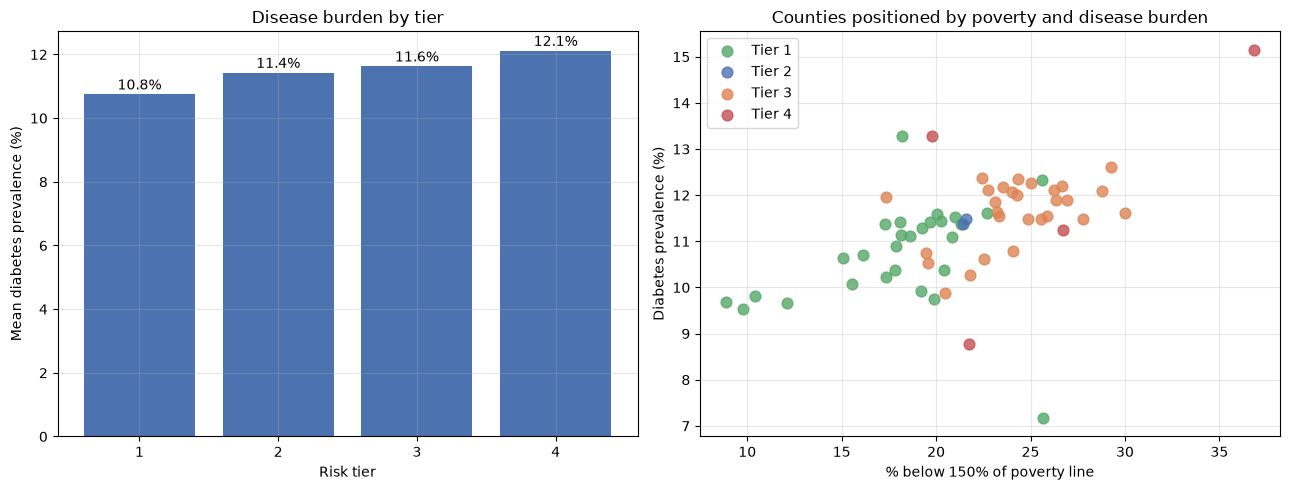

Highest-risk tier:
    county_name  diabetes  ep_pov150
   Bronx County 15.151585  36.814203
  Queens County 13.290497  19.788450
   Kings County 11.249742  26.738452
New York County  8.768421  21.719868


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(tiers.index.astype(str), tiers.diabetes, color='#4C72B0')
axes[0].set_xlabel('Risk tier'); axes[0].set_ylabel('Mean diabetes prevalence (%)')
axes[0].set_title('Disease burden by tier')
for i, v in enumerate(tiers.diabetes):
    axes[0].text(i, v + 0.15, f'{v:.1f}%', ha='center')

palette = ['#55A868', '#4C72B0', '#DD8452', '#C44E52']
for t in sorted(county.risk_tier.unique()):
    sub = county[county.risk_tier == t]
    axes[1].scatter(sub['ep_pov150'], sub[PRIMARY_TARGET], s=60, alpha=0.8,
                    color=palette[t - 1], label=f'Tier {t}')
axes[1].set_xlabel('% below 150% of poverty line')
axes[1].set_ylabel('Diabetes prevalence (%)')
axes[1].set_title('Counties positioned by poverty and disease burden')
axes[1].legend()

plt.tight_layout(); plt.show()

print('Highest-risk tier:')
print(county[county.risk_tier == K][['county_name', 'diabetes', 'ep_pov150']]
      .sort_values('diabetes', ascending=False).to_string(index=False))

In [14]:
out = county[['county_fips', 'county_name', 'risk_tier'] + TARGETS].copy()
out[TARGETS] = out[TARGETS].round(2)
out.to_csv('county_risk_tiers.csv', index=False)
print(f'Wrote county_risk_tiers.csv ({len(out)} counties)')
out.head()

Wrote county_risk_tiers.csv (62 counties)


,county_fips,county_name,risk_tier,diabetes,obesity,bphigh,chd,stroke,copd,cancer
0,36001,Albany County,1,9.75,31.07,32.73,5.59,3.11,6.03,8.25
1,36003,Allegany County,3,11.89,35.77,37.43,7.76,3.95,8.81,9.84
2,36005,Bronx County,4,15.15,33.32,34.78,6.46,4.13,6.69,4.91
3,36007,Broome County,3,11.62,34.71,36.26,7.40,3.95,8.48,9.22
4,36009,Cattaraugus County,3,12.10,35.83,37.82,7.88,4.13,9.30,9.63


### Reading the tiers

The tiers are **multivariate socioeconomic profiles**, not a single severity ranking. Tier
numbering is ordered by mean diabetes prevalence for readability, but the clusters differ
across several dimensions at once and do not line up neatly on every measure, the
highest-diabetes tier has the *lowest* mean obesity, because it is dominated by dense urban
boroughs with high poverty, low vehicle ownership and crowded housing, a profile that
tracks diabetes more strongly than it tracks obesity.

Within-tier spread is also real: the highest tier contains counties ranging from roughly 9%
to 15% diabetes prevalence. The tiers are therefore useful for *grouping counties with
similar structural conditions*  which is what territory and product planning need.

## 8. Feeding insights back into the EDA

The`county_risk_tiers.csv` is loaded back into PostgreSQL as
`eda.county_risk_tier`, keyed on `county_fips`. Because members reach a county through
`member_address → zip_code → county`, model output becomes queryable alongside member,
contract, and claim data:

```sql
SELECT rt.risk_tier,
       count(DISTINCT m.member_id) AS members,
       count(cl.claim_id)          AS claims_2025,
       round(avg(rt.diabetes), 1)  AS tier_diabetes_pct
FROM eda.member m
JOIN eda.member_address ma  ON ma.member_id = m.member_id
JOIN eda.zip_code z         ON z.zip_id = ma.zip_id
JOIN eda.county c           ON c.county_id = z.primary_county_id
JOIN eda.county_risk_tier rt ON rt.county_fips = c.county_fips
LEFT JOIN eda.claim cl ON cl.member_id = m.member_id AND cl.service_year = 2025
GROUP BY rt.risk_tier
ORDER BY rt.risk_tier;
```

### Short, medium, and long term value

| Horizon | Application |
|---|---|
| **Short** | County risk tiers inform territory planning and where to direct servicing capacity, available immediately from `county_risk_tiers.csv`. |
| **Medium** | Tract-level predictions support product design: which wellness riders or preventive benefits to offer in which markets, and where outreach has the most headroom. |
| **Long** | As annual PLACES / SVI / AQI refreshes accumulate, the same pipeline supports trend detection, which areas are deteriorating and eventually claim-cost forecasting once real (non-synthetic) claim history is available. |

